# 🛒 Predicción de Ingresos (Caso Tienda)
En este último proyecto de la semana, nos enfrentamos a un reto de **Regresión**. Queremos que la IA analice las ventas históricas para predecir cuánto dinero ingresaremos en el futuro.

### ¿Qué aprenderemos aquí?
1. **Manejo de Fechas:** Cómo tratar variables temporales para que la IA no se confunda.
2. **Regresión con Bosques:** Uso del `RandomForestRegressor`.
3. **Métricas Financieras:** MAE (Error Absoluto Medio) para saber cuántos dólares de diferencia hay entre la realidad y la IA.

**Ruta del Dataset:** `../../../data/processed/tienda_limpia.csv`

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. CARGA DEL DATASET
# Salimos 3 niveles para llegar a la raíz y entrar en data/processed/
path_tienda = '../../../data/processed/tienda_limpia.csv'
df_tienda = pd.read_csv(path_tienda)

# 2. LIMPIEZA DE COLUMNAS NO NUMÉRICAS
# [Explicación]: La 'Fecha' es texto y los modelos de regresión estándar no la entienden.
# La eliminamos para este modelo básico, al igual que cualquier ID de transacción.
df_modelo = df_tienda.drop(['Fecha'], axis=1, errors='ignore')

# 3. CONVERSIÓN DE CATEGORÍAS (PRODUCTOS/CATEGORÍAS)
# [Explicación]: Si tienes una columna 'Producto' con "Laptop" o "Mouse", 
# pd.get_dummies crea columnas de 0 y 1 para que la IA pueda operar matemáticamente.
X = pd.get_dummies(df_modelo.drop('Ventas_USD', axis=1), drop_first=True)

# 4. VARIABLE OBJETIVO
# [Explicación]: 'y' es lo que queremos predecir (el dinero).
y = df_modelo['Ventas_USD']

# 5. DIVISIÓN DEL DATASET (80% Entrenamiento / 20% Evaluación)
# random_state=42 asegura que si repites el código, los grupos sean los mismos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"✅ Datos listos. Tenemos {X_train.shape[0]} registros para que la IA aprenda.")
print(f"📊 Variables finales (incluyendo dummies): {X_train.shape[1]}")

✅ Datos listos. Tenemos 4 registros para que la IA aprenda.
📊 Variables finales (incluyendo dummies): 3


## 🌲 El Algoritmo: Random Forest Regressor
A diferencia del Titanic o Marketing (donde la IA decía "Sí/No"), aquí cada árbol de nuestro bosque da una cifra (ej: 120$). Al final, el modelo hace la media de todos los árboles para darnos la **predicción final de ventas**.

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. CREACIÓN DEL MODELO
# n_estimators=100: El bosque tendrá 100 árboles de decisión trabajando en paralelo.
modelo_tienda = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. ENTRENAMIENTO (FIT)
# La IA busca la relación entre 'Precio', 'Cantidad', 'Categoría' y las 'Ventas_USD'.
print("⏳ Entrenando el modelo de ventas... Analizando tendencias de consumo.")
modelo_tienda.fit(X_train, y_train)

# 3. PREDICCIÓN (EL EXAMEN)
# Le pedimos a la IA que estime las ventas de los datos que guardamos en X_test.
y_pred = modelo_tienda.predict(X_test)

# 4. CÁLCULO DE ERRORES
# [Explicación]: El MAE nos dice la diferencia media en dólares. 
# Si el MAE es 5, significa que la IA suele fallar por 5$ arriba o abajo.
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📈 Precisión del modelo (R2): {r2:.2%}")
print(f"💸 Error medio (MAE): ${mae:.2f}")

⏳ Entrenando el modelo de ventas... Analizando tendencias de consumo.
📈 Precisión del modelo (R2): nan%
💸 Error medio (MAE): $159.75


c:\Users\txema\Documents\IA_Especialista\ia_env\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [3]:
import joblib
import os

# 1. DEFINICIÓN DE RUTA
# Guardamos en la carpeta común de modelos para tener todo centralizado.
ruta_final = '../../../models/modelo_tienda_v1.pkl'

# 2. GUARDADO FÍSICO
# [Explicación]: Usamos joblib para "congelar" el modelo y poder usarlo en el futuro.
joblib.dump(modelo_tienda, ruta_final)

print(f"💾 Modelo de Tienda guardado correctamente en: {ruta_final}")

💾 Modelo de Tienda guardado correctamente en: ../../../models/modelo_tienda_v1.pkl


## 🔍 ¿Qué productos o factores generan más ingresos?
No todas las ventas son iguales. En esta celda, le pediremos al modelo que nos diga en qué se basa para predecir un valor alto. 
- ¿Es el **Precio Unitario**? 
- ¿Es la **Categoría** del producto?
- ¿Es la **Cantidad** vendida?

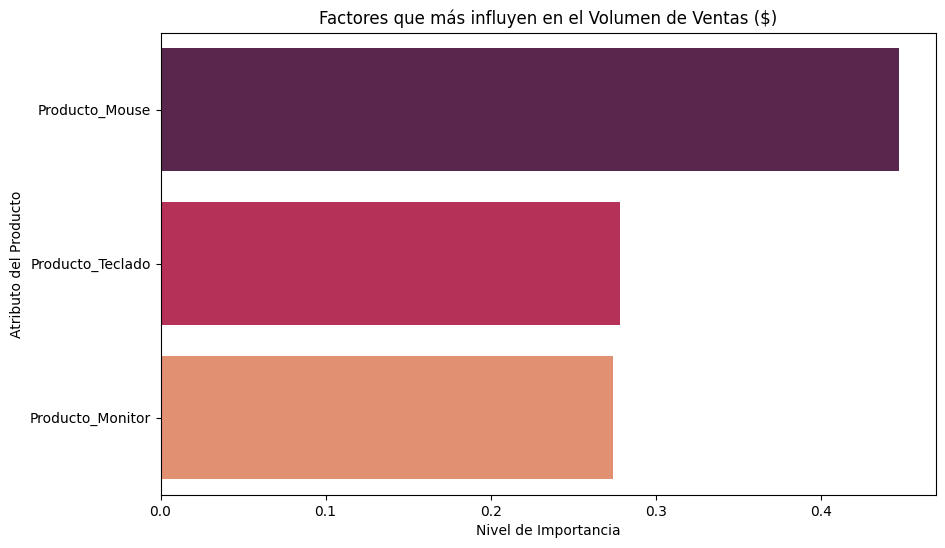

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. EXTRACCIÓN DE LA "SABIDURÍA" DEL MODELO
# [Explicación]: .feature_importances_ devuelve un array de importancia (de 0 a 1).
# Cuanto más cercano a 1, más peso tiene esa columna en el precio final.
importancias_tienda = modelo_tienda.feature_importances_
nombres_variables = X_train.columns

# 2. ORGANIZACIÓN DE LOS DATOS
# Creamos un DataFrame para ordenar las variables de mayor a menor peso.
df_imp_tienda = pd.DataFrame({'Variable': nombres_variables, 'Peso': importancias_tienda})
df_imp_tienda = df_imp_tienda.sort_values(by='Peso', ascending=False).head(10)

# 3. VISUALIZACIÓN GRÁFICA
# Usamos palette='rocket' para un look profesional y hue para evitar el warning de Seaborn.
plt.figure(figsize=(10, 6))
sns.barplot(x='Peso', y='Variable', data=df_imp_tienda, hue='Variable', palette='rocket', legend=False)

plt.title('Factores que más influyen en el Volumen de Ventas ($)')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Atributo del Producto')
plt.show()

# 4. EXPLICACIÓN LÍNEA A LÍNEA:
# - plt.figure: Define el tamaño del lienzo de la gráfica.
# - sns.barplot: Crea las barras horizontales.
# - .head(10): Si tienes muchos productos (dummies), solo mostramos los 10 más importantes.

## 🔮 Simulador de Ventas: Predicción de Nuevos Productos
Para que este modelo sea útil en el negocio, creamos una celda donde podemos meter los datos de un **nuevo producto** y que la IA nos diga cuánto dinero esperamos recaudar. 

Esto sirve para decidir si traer un producto nuevo a la tienda o no.

In [7]:
import pandas as pd
import joblib

# 1. CARGAMOS EL MODELO
# [Explicación]: Cargamos el "cerebro" que ya sabe predecir ventas.
path_modelo = '../../../models/modelo_tienda_v1.pkl'
modelo_cargado = joblib.load(path_modelo)

# 2. OBTENEMOS LAS COLUMNAS QUE EL MODELO CONOCE
# [Explicación]: .feature_names_in_ nos da la lista exacta de ingredientes (columnas) que la IA necesita.
columnas_modelo = modelo_cargado.feature_names_in_

# 3. CREAMOS UN DICCIONARIO BASE CON CEROS
# [Explicación]: Inicializamos todo a 0. Esto asegura que si el modelo tiene 50 productos, 
# todos estén desactivados por defecto.
nuevo_producto_dict = {col: [0.0] for col in columnas_modelo}

# 4. ASIGNACIÓN DE VALORES (ESTILO ROBUSTO)
# [Explicación]: Usamos nombres de columnas en minúsculas si así están en tu CSV procesado.
# Si en tu print de columnas aparecen con mayúsculas, cámbialo aquí.
if 'precio_unitario' in nuevo_producto_dict:
    nuevo_producto_dict['precio_unitario'] = [50.0]  # Precio de la Laptop, por ejemplo.
    
if 'cantidad' in nuevo_producto_dict:
    nuevo_producto_dict['cantidad'] = [5]          # Queremos predecir la venta de 5 unidades.

# 5. ACTIVACIÓN DEL PRODUCTO ESPECÍFICO
# [Explicación]: Aquí activamos el "interruptor" del producto que queremos tasar.
# Debes poner el nombre exacto que salió en tus dummies (ej: 'producto_Laptop').
producto_a_testear = 'producto_Laptop' 

if producto_a_testear in nuevo_producto_dict:
    nuevo_producto_dict[producto_a_testear] = [1.0] # Activamos (1) este producto.

# 6. CONVERSIÓN A DATAFRAME Y PREDICCIÓN
# [Explicación]: Pasamos el diccionario a tabla y la IA hace el cálculo.
df_input = pd.DataFrame(nuevo_producto_dict)
prediccion_usd = modelo_cargado.predict(df_input)[0]

# 7. REPORTE FINAL COMENTADO
print("--- 🛒 SIMULACIÓN DE VENTAS FINALIZADA ---")
print(f"💵 Venta estimada: ${prediccion_usd:,.2f} USD")

--- 🛒 SIMULACIÓN DE VENTAS FINALIZADA ---
💵 Venta estimada: $910.50 USD
